In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [34]:
# Step 3: Load Dataset
import pandas as pd

df = pd.read_csv('train.csv')

In [7]:
# FIRST 5 ROWS
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# DISPLAYING SHAPE
df.shape

(891, 12)

In [9]:
# COLUMN NAMES
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [15]:
# Step 4: Understand Dataset
target = 'Survived'
features = ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']

X = df[features]
y = df[target]

X.head()

,Pclass,Sex,Age,Fare,SibSp,Parch,Embarked
0,3,male,22.0,7.2500,1,0,S
1,1,female,38.0,71.2833,1,0,C
2,3,female,26.0,7.9250,0,0,S
3,1,female,35.0,53.1000,1,0,S
4,3,male,35.0,8.0500,0,0,S


In [14]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [36]:
# Step 5: Data Preprocessing
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [37]:
df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})

/tmp/ipykernel_1335/3114103383.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1})


In [38]:
df = pd.get_dummies(df, columns=['Embarked'])

In [39]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch',
            'Embarked_C', 'Embarked_Q', 'Embarked_S']

X = df[features]

In [40]:
X

,Pclass,Sex,Age,Fare,SibSp,Parch,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.000000,7.2500,1,0,False,False,True
1,1,1,38.000000,71.2833,1,0,True,False,False
2,3,1,26.000000,7.9250,0,0,False,False,True
3,1,1,35.000000,53.1000,1,0,False,False,True
4,3,0,35.000000,8.0500,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...
886,2,0,27.000000,13.0000,0,0,False,False,True
887,1,1,19.000000,30.0000,0,0,False,False,True
888,3,1,29.699118,23.4500,1,2,False,False,True
889,1,0,26.000000,30.0000,0,0,True,False,False


In [41]:
# Step 6: Split Data

from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [44]:
# Step 7: Train Models
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [46]:
# Step 8: Predictions
y_pred_nb = nb_model.predict(X_test)

In [47]:
y_pred_dt = dt_model.predict(X_test)

In [48]:
y_pred_nb

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [50]:
y_pred_dt

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1])

In [53]:
# Step 9: Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [60]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

In [61]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

In [62]:
precision_nb = precision_score(y_test, y_pred_nb)

In [63]:
recall_nb = recall_score(y_test, y_pred_nb)

In [64]:
f1_nb = f1_score(y_test, y_pred_nb)

In [65]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

In [66]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

In [67]:
precision_dt = precision_score(y_test, y_pred_dt)

In [68]:
recall_dt = recall_score(y_test, y_pred_dt)

In [69]:
f1_dt = f1_score(y_test, y_pred_dt)

In [70]:
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_nb)
print("Confusion Matrix:\n", cm_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_dt)
print("Confusion Matrix:\n", cm_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

=== Naive Bayes ===
Accuracy: 0.776536312849162
Confusion Matrix:
 [[82 23]
 [17 57]]
Precision: 0.7125
Recall: 0.7702702702702703
F1 Score: 0.7402597402597403

=== Decision Tree ===
Accuracy: 0.7877094972067039
Confusion Matrix:
 [[88 17]
 [21 53]]
Precision: 0.7571428571428571
Recall: 0.7162162162162162
F1 Score: 0.7361111111111112


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [72]:
cm = confusion_matrix(y_test, y_pred_dt)

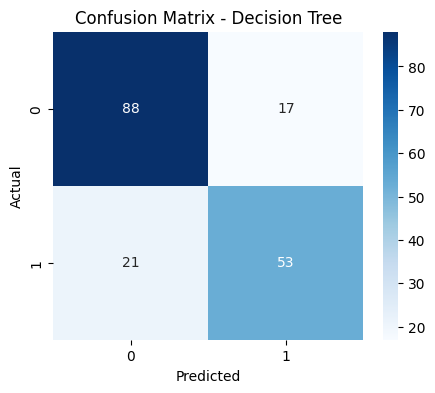

In [73]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()